# ***[🎵 What Makes a Song Popular? — Spotify Tracks EDA](**https://**)***


### **What makes a song popular? 🎧 In this project, we explore 114K+ Spotify tracks to uncover patterns behind song popularity. Using Python, Pandas, and NumPy, we will analyze audio features, genres, artists, and other characteristics to discover interesting insights from the data.**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/spotify-tracks-dataset-detailed.csv")

In [3]:
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
df.tail()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.235,5,-16.393,1,0.0422,0.640,0.928,0.0863,0.0339,125.995,5,world-music
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.117,0,-18.318,0,0.0401,0.994,0.976,0.1050,0.0350,85.239,4,world-music
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.329,0,-10.895,0,0.0420,0.867,0.000,0.0839,0.7430,132.378,4,world-music
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.506,7,-10.889,1,0.0297,0.381,0.000,0.2700,0.4130,135.960,4,world-music
113999,2hETkH7cOfqmz3LqZDHZf5,Cesária Evora,Miss Perfumado,Barbincor,22,241826,False,0.526,0.487,1,-10.204,0,0.0725,0.681,0.000,0.0893,0.7080,79.198,4,world-music


### Understand the Dataset

In [5]:
df.shape

(114000, 20)

In [6]:
df.columns

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')

# Column Description


1.track_id : Unique identifier assigned to each track.

2.artists : Name(s) of the artist(s) who performed the track.

3.album_name : Name of the album containing the track.

4.track_name : Name/title of the track.

5.popularity : Spotify popularity score of the track, ranging from 0 to 100.

6.duration_ms : Duration of the track in milliseconds

7.explicit : Indicates whether the track contains explicit content

8.danceability : Measures how suitable a track is for dancing, from 0 to 1.

9.energy : Measures the intensity and activity level of a track, from 0 to 1.

10.key : Musical key of the track represented as an integer from 0 to 11.

11.loudness : Overall loudness of the track measured in decibels (dB).

12.mode : Indicates the modality of the track: major (1) or minor (0).

13.speechiness : Measures the presence of spoken words in the track, from 0 to 1.

14.acousticness : Confidence that the track is acoustic, from 0 to 1.

15.instrumentalness : Predicts whether a track contains no vocals, from 0 to 1.

16.liveness : Measures the likelihood that the track was recorded with a live audience, from 0 to 1.

17.valence : Measures the musical positivity/happiness of a track, from 0 to 1.

18.tempo : Estimated tempo of the track in beats per minute (BPM).

19.time_signature : Estimated number of beats per measure in the track.

20.track_genre : Genre/category associated with the track.



In [7]:
df.dtypes

,0
track_id,object
artists,object
album_name,object
track_name,object
popularity,int64
duration_ms,int64
explicit,bool
danceability,float64
energy,float64
key,int64


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

In [9]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


## Check data quality

In [10]:
df.isnull().sum()

,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0
key,0


In [11]:
df.duplicated().sum()

np.int64(450)

In [12]:
df[df['track_name'].isnull()]

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,7,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


In [13]:
df.dropna(subset=['track_name'], inplace=True)

In [14]:
df.isnull().sum()

,0
track_id,0
artists,0
album_name,0
track_name,0
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0
key,0


In [15]:
df[df.duplicated()]

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
1925,0CDucx9lKxuCZplLXUz0iX,Buena Onda Reggae Club,Disco 2,Song for Rollins,16,219346,False,0.841,0.577,0,-7.544,1,0.0438,0.238000,0.860000,0.0571,0.843,90.522,4,afrobeat
2155,2aibwv5hGXSgw7Yru8IYTO,Red Hot Chili Peppers,Stadium Arcadium,Snow (Hey Oh),80,334666,False,0.427,0.900,11,-3.674,1,0.0499,0.116000,0.000017,0.1190,0.599,104.655,4,alt-rock
3738,7mULVp0DJrI2Nd6GesLvxn,Joy Division,Timeless Rock Hits,Love Will Tear Us Apart,0,204621,False,0.524,0.902,2,-8.662,1,0.0368,0.000989,0.695000,0.1370,0.907,146.833,4,alternative
4648,6d3RIvHfVkoOtW1WHXmbX3,Little Symphony,Serenity,Margot,27,45714,False,0.269,0.142,0,-23.695,1,0.0509,0.866000,0.904000,0.1140,0.321,67.872,3,ambient
5769,481beimUiUnMUzSbOAFcUT,SUPER BEAVER,突破口 / 自慢になりたい,突破口,54,255080,False,0.472,0.994,8,-1.786,1,0.1140,0.025900,0.000000,0.0535,0.262,103.512,4,anime
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111246,0sSjIvTvd6fUSZZ5rnTPDW,Everything But The Girl,Eden (Deluxe Edition),Another Bridge - 2012 Remaster,26,132826,False,0.480,0.853,0,-6.276,1,0.0734,0.030600,0.000001,0.3200,0.775,85.181,4,trip-hop
111362,2zg3iJW4fK7KZgHOvJU67z,Faithless,Faithless 2.0,Tarantula,21,398152,False,0.622,0.816,6,-11.095,0,0.0483,0.009590,0.578000,0.0991,0.427,136.007,4,trip-hop
111980,46FPub2Fewe7XrgM0smTYI,Morcheeba,Parts of the Process,Undress Me Now,17,203773,False,0.576,0.352,7,-10.773,0,0.0268,0.700000,0.270000,0.1600,0.360,95.484,4,trip-hop
112968,6qVA1MqDrDKfk9144bhoKp,Acil Servis,Küçük Adam,Bebek,38,319933,False,0.486,0.485,5,-12.391,0,0.0331,0.004460,0.000017,0.3690,0.353,120.095,4,turkish


In [16]:
df[df.duplicated(keep=False)].sort_values('track_id').head(10)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
52766,00JZ83w0Qm09f4PwWj06sM,George Jones,With Love,A Good Year For The Roses,12,190546,False,0.491,0.334,11,-9.684,1,0.0287,0.659,0.000016,0.116,0.2490,91.674,4,honky-tonk
52714,00JZ83w0Qm09f4PwWj06sM,George Jones,With Love,A Good Year For The Roses,12,190546,False,0.491,0.334,11,-9.684,1,0.0287,0.659,0.000016,0.116,0.2490,91.674,4,honky-tonk
39275,02KmEChUwcjxG3G29kbLFT,Hans Zimmer;Henning Lohner;Martin Tillman;Fiac...,Hans Zimmer: Epic Scores,Shelter Mountain,16,250520,False,0.144,0.262,9,-21.228,1,0.0641,0.876,0.755000,0.144,0.0345,94.430,4,german
39307,02KmEChUwcjxG3G29kbLFT,Hans Zimmer;Henning Lohner;Martin Tillman;Fiac...,Hans Zimmer: Epic Scores,Shelter Mountain,16,250520,False,0.144,0.262,9,-21.228,1,0.0641,0.876,0.755000,0.144,0.0345,94.430,4,german
93376,02MRylJ1WAgxzdqfNfdIsR,Oleg Pogudin,Любовь и разлука. Песни Исаака Шварца,"Город пышный, город бедный",0,114600,False,0.446,0.121,4,-12.737,0,0.0414,0.937,0.000000,0.125,0.1800,107.573,3,romance
93331,02MRylJ1WAgxzdqfNfdIsR,Oleg Pogudin,Любовь и разлука. Песни Исаака Шварца,"Город пышный, город бедный",0,114600,False,0.446,0.121,4,-12.737,0,0.0414,0.937,0.000000,0.125,0.1800,107.573,3,romance
16747,03B8ZXUmuDpf59j5PIMFHq,Wolfgang Amadeus Mozart;Heinz Holliger;Academy...,Mozart - All Day Classics,"Ma che vi fece... Sperai vicino, K.368: 1. And...",7,86160,False,0.290,0.049,5,-24.072,1,0.0555,0.980,0.753000,0.108,0.1140,76.473,4,classical
16947,03B8ZXUmuDpf59j5PIMFHq,Wolfgang Amadeus Mozart;Heinz Holliger;Academy...,Mozart - All Day Classics,"Ma che vi fece... Sperai vicino, K.368: 1. And...",7,86160,False,0.290,0.049,5,-24.072,1,0.0555,0.980,0.753000,0.108,0.1140,76.473,4,classical
16723,040CvqW0wo3b77EBRfgC14,Wolfgang Amadeus Mozart;Isabelle van Keulen;Ro...,Mozart - A Classical Dawn,Andante and allegretto for Piano and Violin in...,6,84653,False,0.446,0.106,7,-21.427,1,0.0459,0.987,0.696000,0.101,0.8440,157.273,4,classical
16923,040CvqW0wo3b77EBRfgC14,Wolfgang Amadeus Mozart;Isabelle van Keulen;Ro...,Mozart - A Classical Dawn,Andante and allegretto for Piano and Violin in...,6,84653,False,0.446,0.106,7,-21.427,1,0.0459,0.987,0.696000,0.101,0.8440,157.273,4,classical


In [17]:
df.drop_duplicates(inplace=True)

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.shape

(113549, 20)

## **🎵 Part 1 — Understanding song popularity**

In [20]:
df['popularity'].mean()

np.float64(33.32443262380118)

In [21]:
df['popularity'].min()

0

In [22]:
df['popularity'].max()

100

In [23]:
df['popularity'].value_counts().sort_index()

,count
popularity,
0,15843
1,2116
2,1025
3,570
4,377
...,...
96,7
97,8
98,7


# **Find the most popular songs 🎧**

In [24]:
top_10 = df.sort_values('popularity', ascending=False).head(10)[
    ['track_name', 'artists', 'popularity', 'track_genre']
]

top_10

,track_name,artists,popularity,track_genre
20001,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,100,dance
81051,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,100,pop
51664,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,99,hip-hop
81210,I'm Good (Blue),David Guetta;Bebe Rexha,98,pop
30003,I'm Good (Blue),David Guetta;Bebe Rexha,98,edm
67356,La Bachata,Manuel Turizo,98,latin
89411,La Bachata,Manuel Turizo,98,reggaeton
20008,I'm Good (Blue),David Guetta;Bebe Rexha,98,dance
88410,La Bachata,Manuel Turizo,98,reggae
68303,La Bachata,Manuel Turizo,98,latino


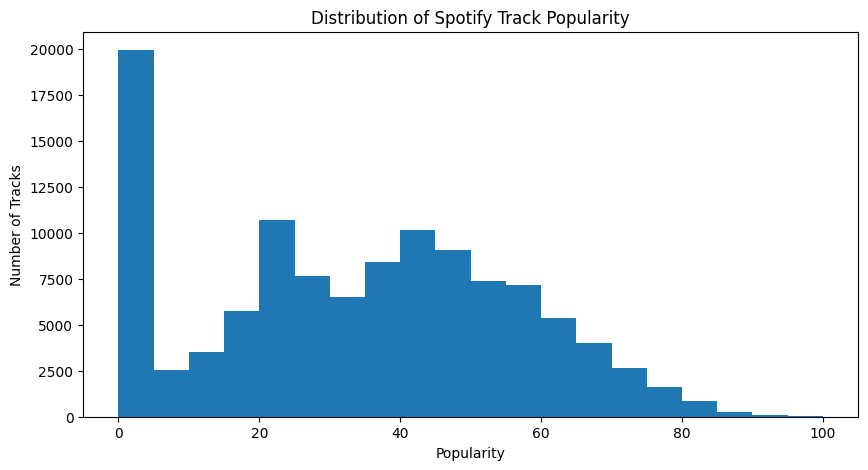

In [25]:
plt.figure(figsize=(10,5))
plt.hist(df['popularity'], bins=20)
plt.xlabel('Popularity')
plt.ylabel('Number of Tracks')
plt.title('Distribution of Spotify Track Popularity')
plt.show()

### **Observation: The distribution shows a large concentration of tracks with very low popularity, particularly at a popularity score of 0. Most tracks fall within the 20–70 range, while highly popular tracks (80+) are relatively rare. This indicates that the dataset contains considerably more less-popular tracks than highly popular ones.**



# 🎼 Which genres have the highest average popularity?

In [26]:
df.groupby('track_genre')['popularity'].mean().sort_values(ascending=False)

,popularity
track_genre,
pop-film,59.280280
k-pop,56.963928
chill,53.704705
sad,52.379000
grunge,49.582583
...,...
chicago-house,12.333667
detroit-techno,11.183367
latin,8.363636


In [27]:
df['track_genre'].value_counts()

,count
track_genre,
acoustic,1000
british,1000
electronic,1000
emo,1000
funk,1000
...,...
honky-tonk,981
dance,965
german,963


In [28]:
genre_analysis = df.groupby('track_genre')['popularity'].agg(['count', 'mean'])
genre_analysis.sort_values('mean', ascending=False).head(10)

,count,mean
track_genre,,
pop-film,999,59.280280
k-pop,998,56.963928
chill,999,53.704705
sad,1000,52.379000
grunge,999,49.582583
indian,999,49.528529
anime,999,48.766767
emo,1000,48.128000
pop,993,47.903323


### **Observation: The dataset contains approximately 1,000 tracks per genre, making the genre distribution relatively balanced. Among the genres analyzed, pop-film has the highest average popularity (59.28), followed by K-pop (56.96) and chill (53.70).**

In [29]:
top_genres = genre_analysis.sort_values('mean', ascending=False).head(10)

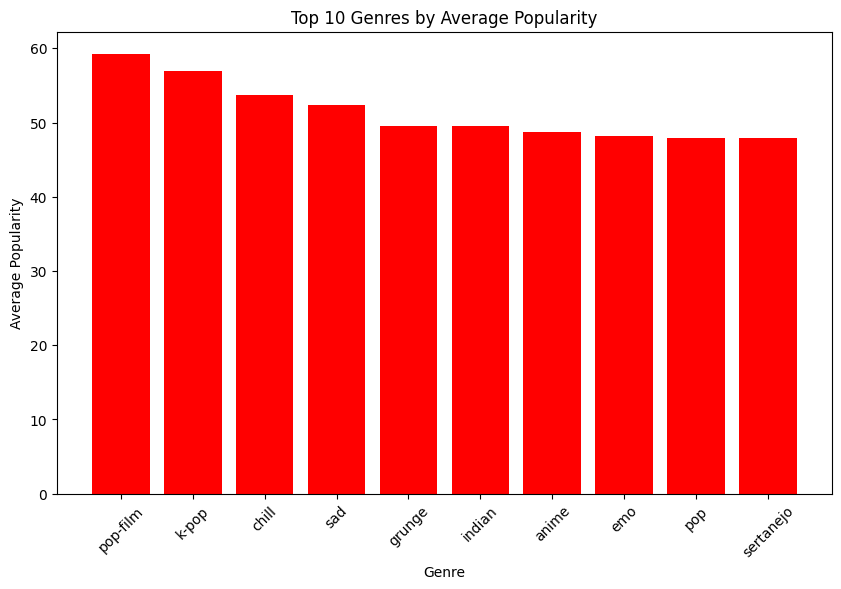

In [30]:
plt.figure(figsize=(10,6))

plt.bar(top_genres.index, top_genres['mean'],color="red")

plt.xlabel('Genre')
plt.ylabel('Average Popularity')
plt.title('Top 10 Genres by Average Popularity')
plt.xticks(rotation=45)
plt.show()

### **Observation: Pop-film has the highest average popularity among the top 10 genres, with an average score of approximately 59.3, followed by K-pop and chill. The difference between the top genres is relatively moderate, suggesting that genre alone may not fully explain a track's popularity.**

# **🎧 Audio Features vs Popularity**

In [31]:
audio_features = [
    'popularity',
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

df[audio_features].corr()['popularity'].sort_values(ascending=False)

,popularity
popularity,1.000000
loudness,0.047368
danceability,0.034407
tempo,0.012187
energy,-0.002447
liveness,-0.005668
acousticness,-0.022356
valence,-0.041097
speechiness,-0.045463
instrumentalness,-0.094718


### **Observation: The correlation analysis shows very weak linear relationships between song popularity and the selected audio features. Loudness has the strongest positive correlation (0.047), while instrumentalness has the strongest negative correlation (-0.095). Overall, these audio features alone do not appear to strongly explain song popularity.**

# **💃 Danceability vs Popularity**

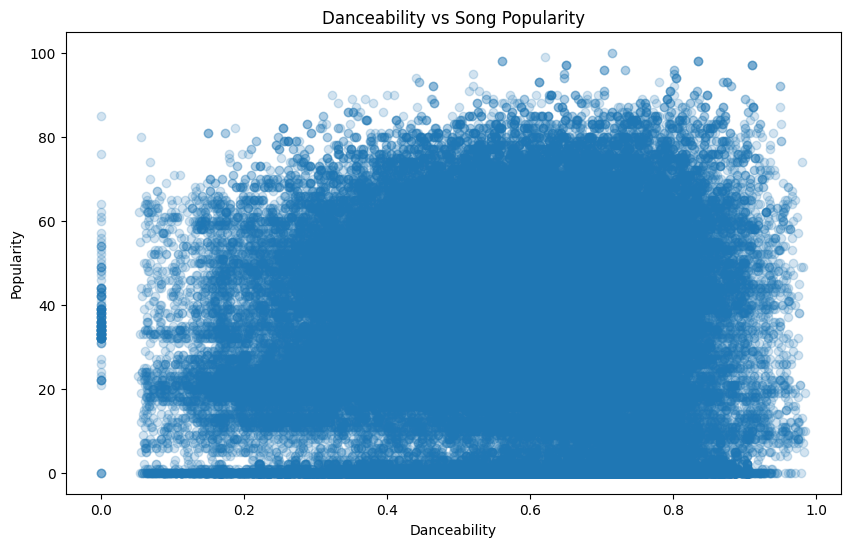

In [32]:
plt.figure(figsize=(10,6))

plt.scatter(df['danceability'], df['popularity'], alpha=0.2)

plt.xlabel('Danceability')
plt.ylabel('Popularity')
plt.title('Danceability vs Song Popularity')

plt.show()

### **Observation: The scatter plot shows that songs with high popularity are distributed across a wide range of danceability values. There is no clear linear relationship between danceability and popularity, which is consistent with the very weak correlation of 0.034**

## **🎧 Do highly popular songs have different audio characteristics from less popular songs?**

In [33]:
popular = df[df['popularity'] >= 70]
less_popular = df[df['popularity'] < 30]

print("Popular tracks:", len(popular))
print("Less popular tracks:", len(less_popular))

Popular tracks: 5468
Less popular tracks: 50090


In [34]:
features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

comparison = pd.DataFrame({
    'Popular Songs': popular[features].mean(),
    'Less Popular Songs': less_popular[features].mean()
})

comparison

,Popular Songs,Less Popular Songs
danceability,0.616063,0.557431
energy,0.671015,0.645819
loudness,-6.663727,-8.492806
speechiness,0.075346,0.095555
acousticness,0.221212,0.317882
instrumentalness,0.036570,0.193845
liveness,0.171995,0.212545
valence,0.504399,0.479800
tempo,120.140603,121.726279


/tmp/ipykernel_1541/3870879281.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


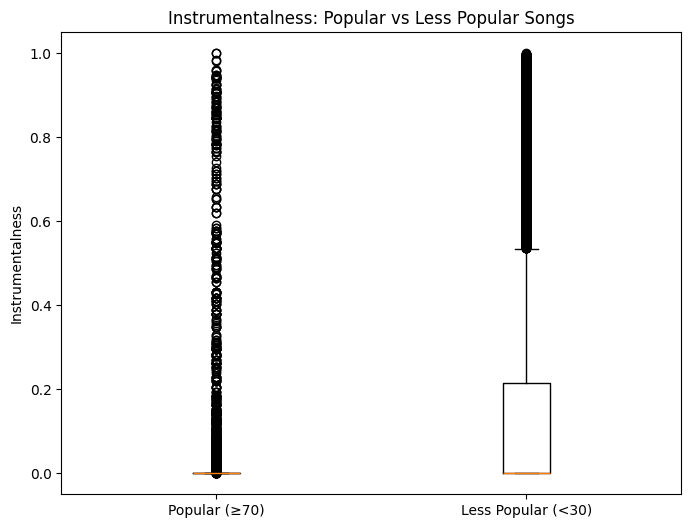

In [35]:
plt.figure(figsize=(8,6))

plt.boxplot(
    [popular['instrumentalness'], less_popular['instrumentalness']],
    labels=['Popular (≥70)', 'Less Popular (<30)']
)

plt.ylabel('Instrumentalness')
plt.title('Instrumentalness: Popular vs Less Popular Songs')

plt.show()

### **Observation: Popular tracks generally have lower instrumentalness than less-popular tracks. The distribution for less-popular tracks is considerably wider, with a larger proportion of tracks having higher instrumentalness values. This suggests that highly popular tracks in this dataset tend to be more vocal-oriented rather than predominantly instrumental.**

/tmp/ipykernel_1541/4192682307.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


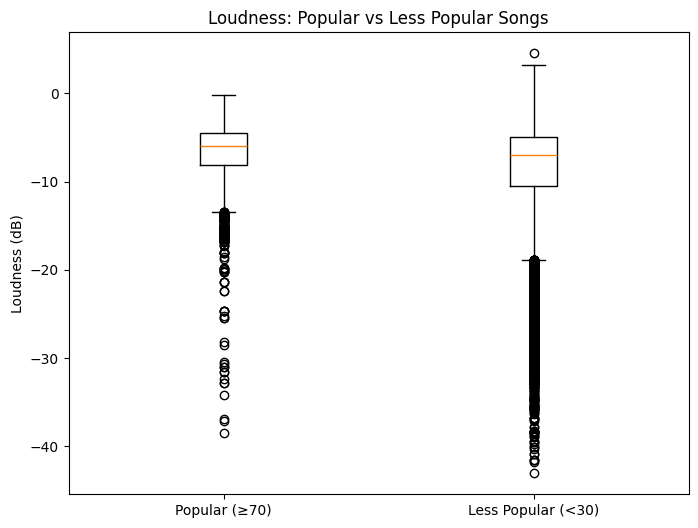

In [36]:
plt.figure(figsize=(8,6))

plt.boxplot(
    [popular['loudness'], less_popular['loudness']],
    labels=['Popular (≥70)', 'Less Popular (<30)']
)

plt.ylabel('Loudness (dB)')
plt.title('Loudness: Popular vs Less Popular Songs')

plt.show()

### **Observation: Popular tracks tend to have higher loudness levels than less-popular tracks. The average loudness of popular tracks is −6.66 dB compared with −8.49 dB for less-popular tracks, indicating that popular tracks in this dataset are generally louder.**

/tmp/ipykernel_1541/1229334193.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


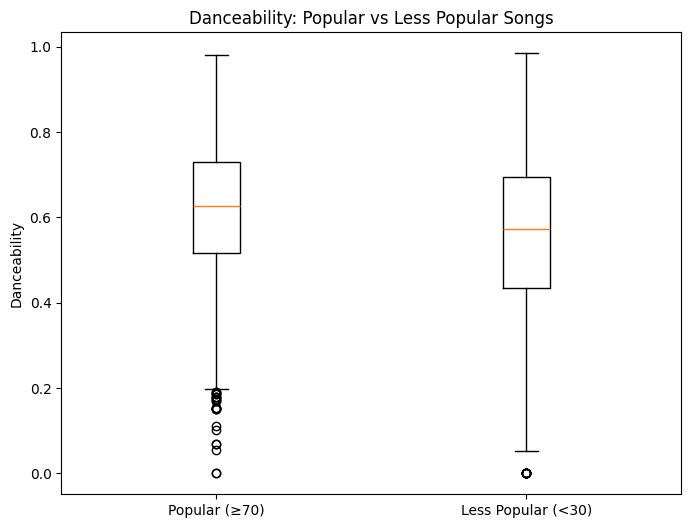

In [37]:
plt.figure(figsize=(8,6))

plt.boxplot(
    [popular['danceability'], less_popular['danceability']],
    labels=['Popular (≥70)', 'Less Popular (<30)']
)

plt.ylabel('Danceability')
plt.title('Danceability: Popular vs Less Popular Songs')

plt.show()

**Observation: Popular tracks have slightly higher danceability than less-popular tracks, with average danceability of 0.616 compared with 0.557. However, the substantial overlap between the two distributions suggests that danceability alone does not strongly distinguish popular songs.**

# **Are explicit songs more popular than non-explicit songs?**

In [38]:
df.groupby('explicit')['popularity'].agg(['count', 'mean'])

,count,mean
explicit,,
False,103831,33.024896
True,9718,36.524799


### Observation: Explicit tracks have a higher average popularity (36.52) than non-explicit tracks (33.02) in this dataset. However, the difference is relatively small, so explicit content alone does not appear to be a strong predictor of popularity.

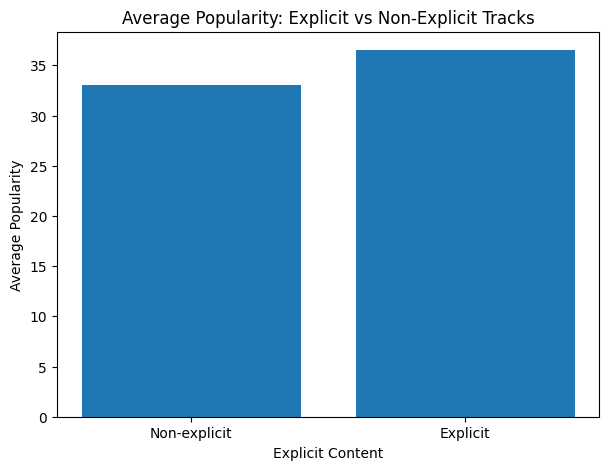

In [39]:
explicit_popularity = df.groupby('explicit')['popularity'].mean()

plt.figure(figsize=(7,5))
plt.bar(['Non-explicit', 'Explicit'], explicit_popularity.values)

plt.xlabel('Explicit Content')
plt.ylabel('Average Popularity')
plt.title('Average Popularity: Explicit vs Non-Explicit Tracks')

plt.show()

# **🎤 Which artists have the highest average popularity?**

In [40]:
df['artists'].nunique()

31437

In [41]:
df['artists'].value_counts().head(10)

,count
artists,
The Beatles,279
George Jones,260
Stevie Wonder,235
Linkin Park,224
Ella Fitzgerald,221
Prateek Kuhad,217
Feid,201
Chuck Berry,190
Håkan Hellström,183


In [42]:
artist_analysis = df.groupby('artists')['popularity'].agg(['count', 'mean'])

artist_analysis = artist_analysis.sort_values('mean', ascending=False)

artist_analysis.head(20)

,count,mean
artists,,
Sam Smith;Kim Petras,2,100.0
Bizarrap;Quevedo,1,99.0
Manuel Turizo,4,98.0
Bad Bunny;Chencho Corleone,4,97.0
Bad Bunny;Bomba Estéreo,4,94.5
Joji,1,94.0
Beyoncé,1,93.0
Harry Styles,3,92.0
Rema;Selena Gomez,1,92.0


In [43]:
top_artists = artist_analysis[artist_analysis['count'] >= 10]

top_artists.sort_values('mean', ascending=False).head(10)

,count,mean
artists,,
Bad Bunny,48,87.083333
Marshmello;Khalid,10,84.000000
Måneskin,12,83.666667
Ariana Grande,11,81.454545
Clairo,10,77.000000
Farruko,13,76.692308
Radiohead,20,76.650000
Travis Scott,18,76.277778
Labrinth,12,76.083333


In [44]:
df['popularity_group'] = pd.cut(
    df['popularity'],
    bins=[-1, 29, 49, 69, 100],
    labels=['Low', 'Medium', 'High', 'Very High']
)

In [45]:
df.groupby('popularity_group', observed=True)['popularity'].agg(['count', 'mean'])

,count,mean
popularity_group,,
Low,50090,12.135177
Medium,34115,40.235937
High,23876,58.153795
Very High,5468,75.891734


### **Observation: The dataset contains 50,090 low-popularity tracks, making them the largest group. Average popularity increases consistently across the four categories, from 12.14 for Low-popularity tracks to 75.89 for Very High-popularity tracks.**

In [46]:
group_features = df.groupby('popularity_group', observed=True)[features].mean()

group_features

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
popularity_group,,,,,,,,,
Low,0.557431,0.645819,-8.492806,0.095555,0.317882,0.193845,0.212545,0.479800,121.726279
Medium,0.568570,0.646338,-8.108068,0.076827,0.324089,0.135100,0.239425,0.484374,123.338819
High,0.573745,0.621575,-8.275343,0.075196,0.312992,0.132405,0.188502,0.441023,121.922922
Very High,0.616063,0.671015,-6.663727,0.075346,0.221212,0.036570,0.171995,0.504399,120.140603


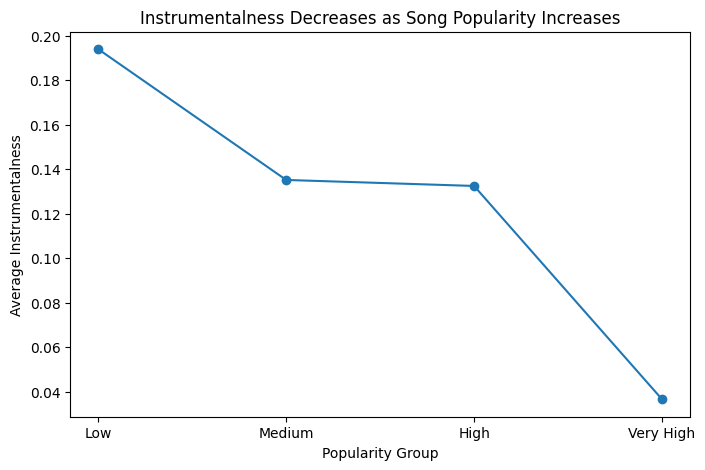

In [47]:
plt.figure(figsize=(8,5))

plt.plot(
    group_features.index,
    group_features['instrumentalness'],
    marker='o'
)

plt.xlabel('Popularity Group')
plt.ylabel('Average Instrumentalness')
plt.title('Instrumentalness Decreases as Song Popularity Increases')

plt.show()

### **Observation: Average instrumentalness decreases substantially as song popularity increases. Very high-popularity tracks have an average instrumentalness of only 0.037, compared with 0.194 for low-popularity tracks. This suggests that highly popular tracks in this dataset tend to be less instrumental.**

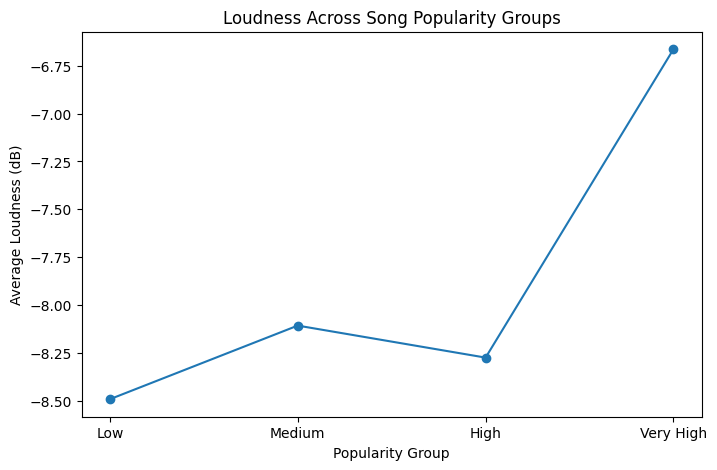

In [48]:
plt.figure(figsize=(8,5))

plt.plot(
    group_features.index,
    group_features['loudness'],
    marker='o'
)

plt.xlabel('Popularity Group')
plt.ylabel('Average Loudness (dB)')
plt.title('Loudness Across Song Popularity Groups')

plt.show()

### **Observation: Very high-popularity tracks have noticeably higher average loudness (−6.66 dB) compared with low-popularity tracks (−8.49 dB). Although the trend is not perfectly consistent across all groups, highly popular tracks in this dataset tend to be louder.**

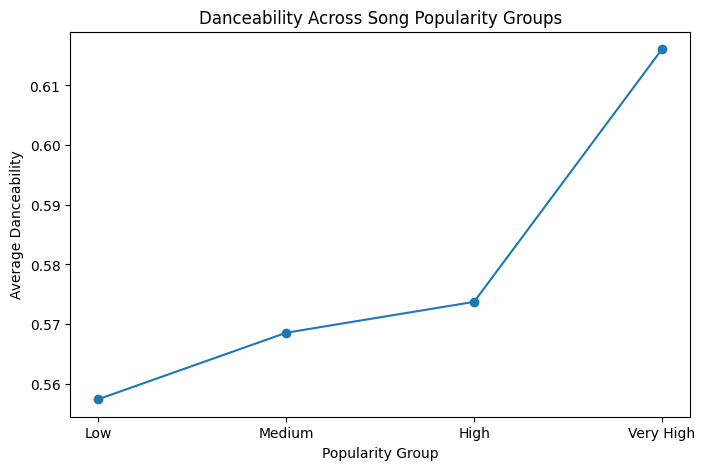

In [49]:
plt.figure(figsize=(8,5))

plt.plot(
    group_features.index,
    group_features['danceability'],
    marker='o'
)

plt.xlabel('Popularity Group')
plt.ylabel('Average Danceability')
plt.title('Danceability Across Song Popularity Groups')

plt.show()

**Observation: Average danceability increases consistently with song popularity, rising from 0.557 for low-popularity tracks to 0.616 for very high-popularity tracks. This suggests that highly popular tracks in this dataset tend to be more danceable.**

In [50]:
group_features[['danceability', 'loudness', 'instrumentalness']]

,danceability,loudness,instrumentalness
popularity_group,,,
Low,0.557431,-8.492806,0.193845
Medium,0.568570,-8.108068,0.135100
High,0.573745,-8.275343,0.132405
Very High,0.616063,-6.663727,0.036570


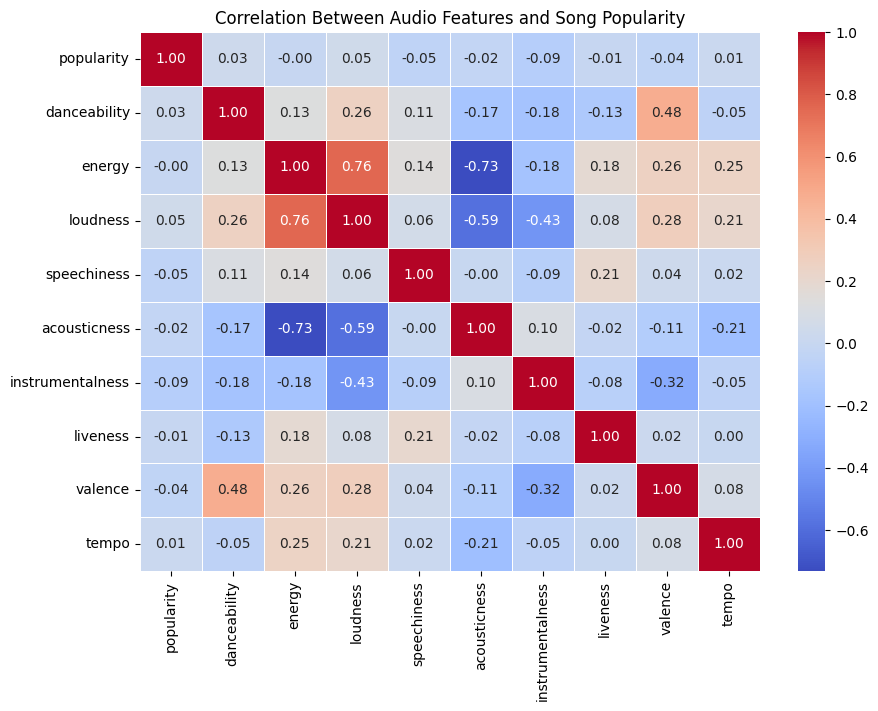

In [55]:
corr = df[audio_features].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Between Audio Features and Song Popularity')
plt.show()

## 🎯 Key Findings

- Very high-popularity tracks tend to have **lower instrumentalness**, with the average decreasing from 0.194 in the Low group to 0.037 in the Very High group.
- Very high-popularity tracks tend to be **louder**, with average loudness increasing from -8.49 dB to -6.66 dB.
- **Danceability increases** across popularity groups, from 0.557 for Low-popularity tracks to 0.616 for Very High-popularity tracks.
- **Pop-film, K-pop, and Chill** were among the genres with the highest average popularity in this dataset.
- Explicit tracks had a slightly higher average popularity (**36.52**) than non-explicit tracks (**33.02**).
- Overall correlations between individual audio features and popularity were weak, suggesting that **no single audio feature strongly determines song popularity**.

> **Note:** These findings describe associations observed in the dataset and do not imply that these audio features directly cause a song to become popular.